In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.head()

,X,Y,class
0,0.0316,0.9870,0.0
1,2.1200,-0.0462,1.0
2,0.8820,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8300,-0.5390,1.0


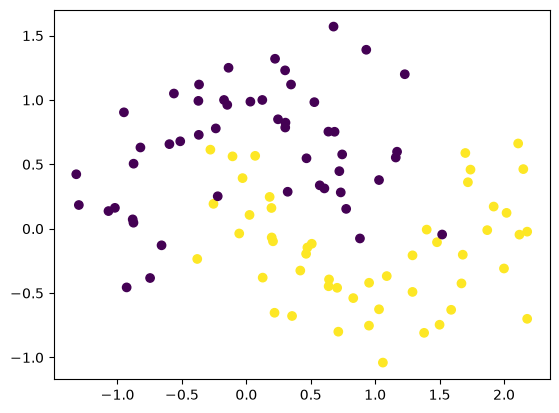

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [7]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.get_weights()

[array([[ 0.1617387 ,  0.44878814,  1.4851985 , -0.9678243 , -1.0656791 ,
          0.6151815 , -1.3699493 , -0.22048907,  1.4265776 , -0.28616178],
        [ 0.23306596, -0.38513416, -0.02749058, -0.9335357 , -1.0711974 ,
         -0.91480917,  1.355338  , -0.67089653,  0.36939085, -0.7657332 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.38886735, -0.08974462,  0.6039466 , -0.49450186,  0.08848033,
         -0.46425638, -0.05713869, -0.46293566, -0.7101288 ,  0.44366443],
        [-0.7057184 ,  0.6021497 , -0.30789593, -0.3222294 ,  0.4636143 ,
          0.6136245 , -0.35723504, -0.93903387,  0.32048237,  0.7333079 ],
        [ 0.76074857, -0.6367611 , -0.16590211, -0.5783765 ,  0.46680063,
         -0.79467297, -0.27728066,  0.20817491,  0.2134001 ,  0.30071303],
        [ 0.0522691 , -0.7901115 , -0.63310206,  0.56690097, -0.7264582 ,
          0.8100493 ,  0.1906459 , -0.08100868,  0.40235877, -0.5694218 ],
        [-0.71719

In [9]:
initial_weights = model.get_weights()

In [10]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [11]:
model.set_weights(initial_weights)

In [12]:
model.get_weights()

[array([[-0.1483233 , -0.12055822,  0.19545287,  0.5864897 , -0.83182544,
         -0.2774853 ,  0.5873074 , -2.0057142 , -0.54297227, -0.31399712],
        [ 0.0406477 , -0.23641886, -0.4031184 ,  0.57975096, -0.09357975,
          0.6428582 , -0.71608704,  0.49695337, -1.7290167 , -0.81509906]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.29303414, -0.11946669,  0.7208    , -0.17911121,  0.3500093 ,
         -0.11278713, -0.15160558, -0.13536721,  0.45548245,  0.07940222],
        [-0.11068629,  0.39968416,  0.55084527,  0.28196076, -0.67291087,
         -0.6026712 ,  0.16172072, -0.01440162, -0.08171033, -0.06102143],
        [ 0.7078812 , -0.1984959 , -0.61058915,  0.05813073,  0.0991118 ,
          0.03966979, -0.274077  , -1.1073573 , -0.13082305,  0.4827035 ],
        [ 0.29051217, -0.0593413 , -0.56932265, -0.11551244, -0.04427245,
         -0.3641041 , -0.02783677, -0.01803424, -0.17709242,  0.06004976],
        [-0.15947

In [13]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [14]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.5000 - loss: 0.6731 - val_accuracy: 0.5000 - val_loss: 0.6228
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5000 - loss: 0.6689 - val_accuracy: 0.5000 - val_loss: 0.6162
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5000 - loss: 0.6648 - val_accuracy: 0.5000 - val_loss: 0.6094
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5000 - loss: 0.6613 - val_accuracy: 0.5000 - val_loss: 0.6022
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 0.6575 - val_accuracy: 0.5000 - val_loss: 0.5950
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5000 - loss: 0.6537 - val_accuracy: 0.5000 - val_loss: 0.5880
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5250 - loss: 0.6502 - val_accuracy: 0.5500 - val_loss: 0.5807
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5625 - loss: 0.6469 - val_accuracy: 0.7500 - val_loss

In [15]:
model.get_weights()

[array([[-3.2626706e-01,  1.3147899e-03,  1.7946470e-01,  7.1052212e-01,
         -8.7866133e-01, -2.1403991e-01,  6.6865522e-01, -2.0226154e+00,
         -6.9884008e-01, -4.3598062e-01],
        [ 5.7951752e-02, -2.8308156e-01, -5.0250226e-01,  6.9515091e-01,
         -4.3671452e-02,  8.5435766e-01, -8.6198908e-01,  5.8925635e-01,
         -1.6359737e+00, -7.2297740e-01]], dtype=float32),
 array([ 0.16958877, -0.05635917,  0.11145487,  0.07385123, -0.1143347 ,
         0.01476028, -0.10208291, -0.10151492, -0.06007534, -0.07033326],
       dtype=float32),
 array([[-0.5116855 , -0.2032435 ,  0.659896  , -0.17772289,  0.44715756,
         -0.1117292 , -0.20148319, -0.16712108,  0.44830835,  0.00240328],
        [-0.11236177,  0.37917626,  0.55084527,  0.19915092, -0.54551727,
         -0.7054427 ,  0.14963672, -0.00168358, -0.05957978, -0.01308437],
        [ 0.5792323 , -0.47225666, -0.61058915,  0.04131393,  0.2718887 ,
         -0.07398904, -0.10540363, -1.3252424 , -0.3210024 ,  0.4

<Axes: >

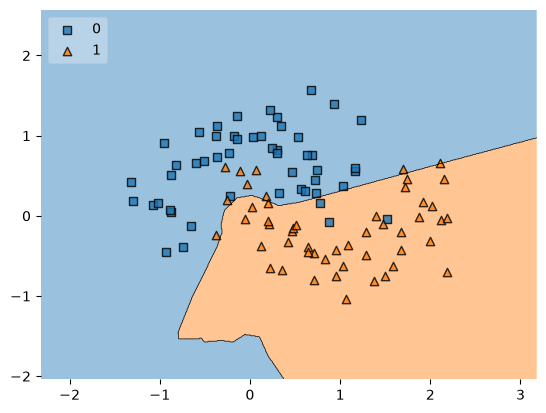

In [16]:
from mlxtend.plotting import plot_decision_regions

class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        return (self.model.predict(X, verbose=0) > 0.5).astype(int).ravel()

clf = KerasClassifierWrapper(model)
plot_decision_regions(X,y.astype('int'), clf=clf, legend=2)

In [17]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.021183039337490373)

In [18]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.038366025609457365)